# 01 Download Data

This notebook downloads Sentinel-2 scenes, saves them to Google Drive, and writes manifest files so the workflow can resume after Colab resets.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Clone repo (safe re-run)
import os

if not os.path.exists("/content/WaterDetectionProjectRepo"):
    !git clone https://github.com/parthpatel182003/Sentinel-2.git /content/WaterDetectionProjectRepo

%cd /content/WaterDetectionProjectRepo

/content/WaterDetectionProjectRepo


In [13]:
!pip install earthengine-api geemap

In [14]:
import sys
from pathlib import Path

REPO_ROOT = Path('/content/WaterDetectionProjectRepo')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.config import PROJECT_CONFIG, PATHS, ensure_project_dirs

ensure_project_dirs()

print("Project config loaded")
PROJECT_CONFIG

Project config loaded


{'project_name': 'water-detection-remote-sensing',
 'dataset_name': 'sentinel-2-l2a',
 'aoi_name': 'replace_with_aoi_name',
 'start_date': '2024-01-01',
 'end_date': '2024-12-31',
 'max_cloud_cover': 20,
 'phase1_indices': ['NDWI', 'MNDWI'],
 'phase2_model_name': 'unet',
 'patch_size': 256,
 'patch_stride': 256,
 'batch_size': 8,
 'num_epochs': 20,
 'learning_rate': 0.001,
 'random_seed': 42}

## To Implement

- set AOI geometry
- choose API client
- query scenes
- filter by cloud cover
- save scene manifest
- download missing scenes only

In [6]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project="my-project-69425sentinel")

In [7]:
import json
import os
from datetime import datetime

from src.config import PROJECT_CONFIG, PATHS, ensure_project_dirs

ensure_project_dirs()

print("Project paths ready")

Project paths ready


In [15]:
import os

image_dir = "/content/drive/MyDrive/WaterDetectionProject_exports"

files = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])

print(f"Found {len(files)} TIFF files:\n")

for f in files:
    print(" -", f)

Found 4 TIFF files:

 - kuttanad_kerala_scene_1.tif
 - kuttanad_kerala_scene_2.tif
 - kuttanad_kerala_scene_3.tif
 - kuttanad_s2_first_image.tif


In [16]:
import pandas as pd

data = []

for f in files:
    data.append({
        "filename": f,
        "path": os.path.join(image_dir, f)
    })

df = pd.DataFrame(data)

save_path = "/content/drive/MyDrive/WaterDetectionProject/scene_inventory.csv"
df.to_csv(save_path, index=False)

print("\nScene inventory saved at:", save_path)
df


Scene inventory saved at: /content/drive/MyDrive/WaterDetectionProject/scene_inventory.csv


,filename,path
0,kuttanad_kerala_scene_1.tif,/content/drive/MyDrive/WaterDetectionProject_e...
1,kuttanad_kerala_scene_2.tif,/content/drive/MyDrive/WaterDetectionProject_e...
2,kuttanad_kerala_scene_3.tif,/content/drive/MyDrive/WaterDetectionProject_e...
3,kuttanad_s2_first_image.tif,/content/drive/MyDrive/WaterDetectionProject_e...


In [8]:
# Kerala flood-prone region (you can change later)
aoi = ee.Geometry.Rectangle([76.3, 9.2, 76.6, 9.6])

Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(aoi, {}, "AOI")
Map

Map(center=[9.39999311259073, 76.45000000000076], controls=(WidgetControl(options=['position', 'transparent_bg…

(np.float64(-0.5), np.float64(2764.5), np.float64(4435.5), np.float64(-0.5))

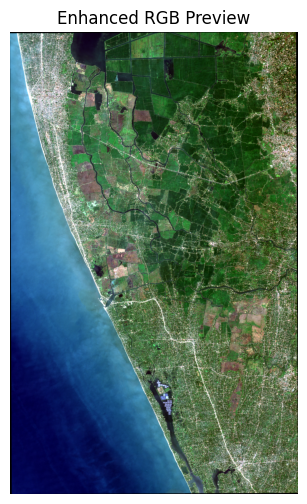

In [18]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

sample_path = df.iloc[0]["path"]

with rasterio.open(sample_path) as src:
    red = src.read(3).astype(np.float32)
    green = src.read(2).astype(np.float32)
    blue = src.read(1).astype(np.float32)

# Normalize using percentile stretch (important)
def normalize_band(band):
    p2, p98 = np.percentile(band, (2, 98))
    band = np.clip(band, p2, p98)
    return (band - p2) / (p98 - p2 + 1e-6)

red_n = normalize_band(red)
green_n = normalize_band(green)
blue_n = normalize_band(blue)

rgb = np.stack([red_n, green_n, blue_n], axis=-1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Enhanced RGB Preview")
plt.axis("off")

In [20]:
!git config --global user.email "parth.patel182003@gmail.com"
!git config --global user.name "parthpatel182003"

In [21]:
!git add .
!git commit -m "completed notebook1 setup (inventory + preview)"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
